# Player CLustering

**Project:** Game-aware NPC: Player Based NPC Behavior Generation for Blockchain Gaming

**Dataset:** Predict Online Gaming Behavior (Kaggle)

**Purpose:** Player archetype clustering (K-Means)

---

In [1]:
import pandas as pd, numpy as np
import os; 
os.makedirs('Clustering_figures', exist_ok=True)

In [2]:
df = pd.read_csv('online_gaming_behavior_dataset.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (40034, 13)


,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40034 entries, 0 to 40033
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PlayerID                   40034 non-null  int64  
 1   Age                        40034 non-null  int64  
 2   Gender                     40034 non-null  object 
 3   Location                   40034 non-null  object 
 4   GameGenre                  40034 non-null  object 
 5   PlayTimeHours              40034 non-null  float64
 6   InGamePurchases            40034 non-null  int64  
 7   GameDifficulty             40034 non-null  object 
 8   SessionsPerWeek            40034 non-null  int64  
 9   AvgSessionDurationMinutes  40034 non-null  int64  
 10  PlayerLevel                40034 non-null  int64  
 11  AchievementsUnlocked       40034 non-null  int64  
 12  EngagementLevel            40034 non-null  object 
dtypes: float64(1), int64(7), object(5)
memory usag

In [4]:
df.describe()

,PlayerID,Age,PlayTimeHours,InGamePurchases,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked
count,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000,40034.000000
mean,29016.500000,31.992531,12.024365,0.200854,9.471774,94.792252,49.655568,24.526477
std,11556.964675,10.043227,6.914638,0.400644,5.763667,49.011375,28.588379,14.430726
min,9000.000000,15.000000,0.000115,0.000000,0.000000,10.000000,1.000000,0.000000
25%,19008.250000,23.000000,6.067501,0.000000,4.000000,52.000000,25.000000,12.000000
50%,29016.500000,32.000000,12.008002,0.000000,9.000000,95.000000,49.000000,25.000000
75%,39024.750000,41.000000,17.963831,0.000000,14.000000,137.000000,74.000000,37.000000
max,49033.000000,49.000000,23.999592,1.000000,19.000000,179.000000,99.000000,49.000000


In [5]:
df.isnull().sum()

PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64

In [6]:
categorical_cols = ['Gender','Location', 'GameGenre','GameDifficulty','EngagementLevel']
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Gender:
Gender
Male      23959
Female    16075
Name: count, dtype: int64

Location:
Location
USA       16000
Europe    12004
Asia       8095
Other      3935
Name: count, dtype: int64

GameGenre:
GameGenre
Sports        8048
Action        8039
Strategy      8012
Simulation    7983
RPG           7952
Name: count, dtype: int64

GameDifficulty:
GameDifficulty
Easy      20015
Medium    12011
Hard       8008
Name: count, dtype: int64

EngagementLevel:
EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64


In [7]:
engagement_counts = df['EngagementLevel'].value_counts()
print(engagement_counts)
print(f"\nPercentages:")
print(df['EngagementLevel'].value_counts(normalize=True) * 100)

EngagementLevel
Medium    19374
High      10336
Low       10324
Name: count, dtype: int64

Percentages:
EngagementLevel
Medium    48.393865
High      25.818055
Low       25.788080
Name: proportion, dtype: float64


In [8]:
numeric_cols = ['PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 
                'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']

print("=== NUMERIC FEATURES SUMMARY ===\n")
for col in numeric_cols:
    print(f"{col}:")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}, Mean: {df[col].mean():.2f}")
    print()

=== NUMERIC FEATURES SUMMARY ===

PlayTimeHours:
  Min: 0.0001146866199155, Max: 23.999591633580454, Mean: 12.02

InGamePurchases:
  Min: 0, Max: 1, Mean: 0.20

SessionsPerWeek:
  Min: 0, Max: 19, Mean: 9.47

AvgSessionDurationMinutes:
  Min: 10, Max: 179, Mean: 94.79

PlayerLevel:
  Min: 1, Max: 99, Mean: 49.66

AchievementsUnlocked:
  Min: 0, Max: 49, Mean: 24.53



In [9]:
print("InGamePurchases unique values:", df['InGamePurchases'].unique())
print("\nPurchase distribution:")
print(df['InGamePurchases'].value_counts())
print(f"\nOnly {df['InGamePurchases'].mean()*100:.1f}% of players make purchases")

InGamePurchases unique values: [0 1]

Purchase distribution:
InGamePurchases
0    31993
1     8041
Name: count, dtype: int64

Only 20.1% of players make purchases


In [10]:
print("=== ENGAGEMENT vs PURCHASES ===\n")
purchase_by_engagement = df.groupby('EngagementLevel')['InGamePurchases'].mean() * 100
print("Purchase rate by engagement level:")
print(purchase_by_engagement.round(1))

=== ENGAGEMENT vs PURCHASES ===

Purchase rate by engagement level:
EngagementLevel
High      20.6
Low       19.7
Medium    20.0
Name: InGamePurchases, dtype: float64


In [11]:
print("=== WHAT PREDICTS HIGH ENGAGEMENT? ===\n")

for col in ['PlayTimeHours', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']:
    print(f"\n{col} by Engagement:")
    print(df.groupby('EngagementLevel')[col].mean().round(2))

=== WHAT PREDICTS HIGH ENGAGEMENT? ===


PlayTimeHours by Engagement:
EngagementLevel
High      12.07
Low       12.10
Medium    11.96
Name: PlayTimeHours, dtype: float64

SessionsPerWeek by Engagement:
EngagementLevel
High      14.25
Low        4.53
Medium     9.55
Name: SessionsPerWeek, dtype: float64

AvgSessionDurationMinutes by Engagement:
EngagementLevel
High      131.92
Low        66.88
Medium     89.86
Name: AvgSessionDurationMinutes, dtype: float64

PlayerLevel by Engagement:
EngagementLevel
High      50.82
Low       46.10
Medium    50.93
Name: PlayerLevel, dtype: float64

AchievementsUnlocked by Engagement:
EngagementLevel
High      25.10
Low       22.66
Medium    25.22
Name: AchievementsUnlocked, dtype: float64


In [12]:
clustering_features = [
    'SessionsPerWeek',
    'AvgSessionDurationMinutes',
    'PlayerLevel',
    'AchievementsUnlocked',
    'InGamePurchases'
]

X = df[clustering_features].copy()
print(f"Shape: {X.shape}")
X.head()

Shape: (40034, 5)


,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,InGamePurchases
0,6,108,79,25,0
1,5,144,11,10,0
2,16,142,35,41,0
3,9,85,57,47,1
4,2,131,95,37,0


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling (first row):")
print(dict(zip(clustering_features, X.iloc[0].values)))

print("\nAfter scaling (first row):")
print(dict(zip(clustering_features, X_scaled[0].round(3))))

Before scaling (first row):
{'SessionsPerWeek': 6, 'AvgSessionDurationMinutes': 108, 'PlayerLevel': 79, 'AchievementsUnlocked': 25, 'InGamePurchases': 0}

After scaling (first row):
{'SessionsPerWeek': -0.602, 'AvgSessionDurationMinutes': 0.269, 'PlayerLevel': 1.026, 'AchievementsUnlocked': 0.033, 'InGamePurchases': -0.501}


In [14]:
from sklearn.cluster import KMeans

# Try different numbers of clusters
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"k={k}: inertia={kmeans.inertia_:.2f}")

k=2: inertia=160132.87
k=3: inertia=136048.75
k=4: inertia=121427.38
k=5: inertia=109771.95
k=6: inertia=100846.28
k=7: inertia=94680.67
k=8: inertia=88362.80
k=9: inertia=82402.09
k=10: inertia=76203.98


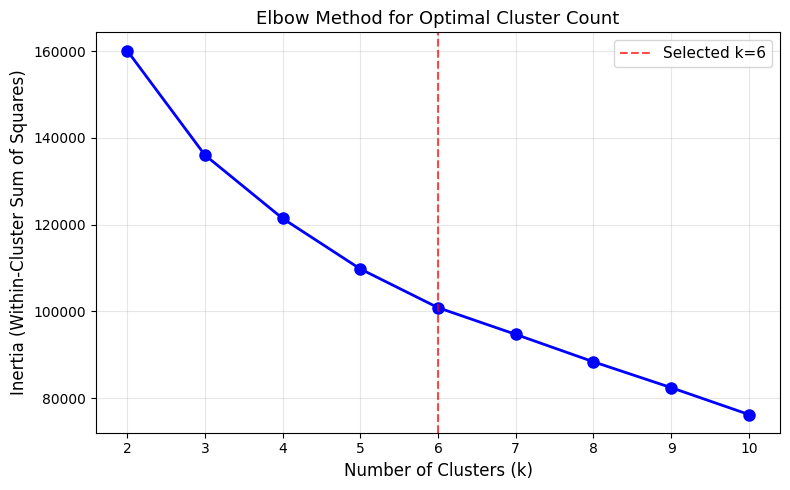

In [15]:
# Elbow Method for Optimal k

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(range(2, 11)), inertias, 'bo-', linewidth=2, markersize=8)
ax.axvline(x=6, color='red', linestyle='--', alpha=0.7, label='Selected k=6')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax.set_title('Elbow Method for Optimal Cluster Count', fontsize=13)
ax.set_xticks(list(range(2, 11)))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('Clustering_figures/fig_4_1_elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
print("Rate of decrease:")
for i in range(1, len(inertias)):
    drop = inertias[i-1] - inertias[i]
    print(f"k={i+2}: drop = {drop:.0f}")

Rate of decrease:
k=3: drop = 24084
k=4: drop = 14621
k=5: drop = 11655
k=6: drop = 8926
k=7: drop = 6166
k=8: drop = 6318
k=9: drop = 5961
k=10: drop = 6198


### Decision is k=6

In [17]:
# Final clustering
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['PlayerArchetype'] = kmeans.fit_predict(X_scaled)

print("Players per cluster:")
print(df['PlayerArchetype'].value_counts().sort_index())

Players per cluster:
PlayerArchetype
0    6212
1    6150
2    8040
3    6592
4    6619
5    6421
Name: count, dtype: int64


### Cluster Profiles

In [18]:
print("=== CLUSTER PROFILES ===\n")

for cluster in range(6):
    cluster_data = df[df['PlayerArchetype'] == cluster]
    print(f"--- Cluster {cluster} ({len(cluster_data)} players) ---")
    for col in clustering_features:
        mean_val = cluster_data[col].mean()
        overall_mean = df[col].mean()
        diff = ((mean_val - overall_mean) / overall_mean) * 100
        direction = "↑" if diff > 10 else "↓" if diff < -10 else "→"
        print(f"  {col}: {mean_val:.1f} ({direction} {diff:+.0f}%)")
    print()

=== CLUSTER PROFILES ===

--- Cluster 0 (6212 players) ---
  SessionsPerWeek: 12.3 (↑ +30%)
  AvgSessionDurationMinutes: 95.7 (→ +1%)
  PlayerLevel: 76.9 (↑ +55%)
  AchievementsUnlocked: 37.0 (↑ +51%)
  InGamePurchases: 0.0 (↓ -100%)

--- Cluster 1 (6150 players) ---
  SessionsPerWeek: 14.7 (↑ +55%)
  AvgSessionDurationMinutes: 130.1 (↑ +37%)
  PlayerLevel: 35.8 (↓ -28%)
  AchievementsUnlocked: 16.3 (↓ -34%)
  InGamePurchases: 0.0 (↓ -100%)

--- Cluster 2 (8040 players) ---
  SessionsPerWeek: 9.5 (→ +1%)
  AvgSessionDurationMinutes: 94.5 (→ -0%)
  PlayerLevel: 50.0 (→ +1%)
  AchievementsUnlocked: 24.5 (→ +0%)
  InGamePurchases: 1.0 (↑ +398%)

--- Cluster 3 (6592 players) ---
  SessionsPerWeek: 3.7 (↓ -61%)
  AvgSessionDurationMinutes: 139.8 (↑ +47%)
  PlayerLevel: 48.5 (→ -2%)
  AchievementsUnlocked: 23.9 (→ -2%)
  InGamePurchases: 0.0 (↓ -100%)

--- Cluster 4 (6619 players) ---
  SessionsPerWeek: 8.2 (↓ -14%)
  AvgSessionDurationMinutes: 52.8 (↓ -44%)
  PlayerLevel: 61.7 (↑ +24%)
  Ac

In [19]:
print("=== PURCHASE RATE BY CLUSTER ===\n")
for cluster in range(6):
    cluster_data = df[df['PlayerArchetype'] == cluster]
    purchase_rate = cluster_data['InGamePurchases'].mean() * 100
    print(f"Cluster {cluster}: {purchase_rate:.1f}% purchase rate")

=== PURCHASE RATE BY CLUSTER ===

Cluster 0: 0.0% purchase rate
Cluster 1: 0.0% purchase rate
Cluster 2: 100.0% purchase rate
Cluster 3: 0.0% purchase rate
Cluster 4: 0.0% purchase rate
Cluster 5: 0.0% purchase rate


In [20]:
archetype_names = {
    0: 'Achievement Hunter',
    1: 'Engaged Beginner', 
    2: 'Spender',
    3: 'Weekend Warrior',
    4: 'Casual Veteran',
    5: 'Trophy Hunter'
}

df['ArchetypeName'] = df['PlayerArchetype'].map(archetype_names)
print(df['ArchetypeName'].value_counts())

ArchetypeName
Spender               8040
Casual Veteran        6619
Weekend Warrior       6592
Trophy Hunter         6421
Achievement Hunter    6212
Engaged Beginner      6150
Name: count, dtype: int64


In [21]:
# Save the dataframe with archetypes
output_path = 'players_with_archetypes.csv'
df.to_csv(output_path, index=False)
print(f"Saved to {output_path}")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Saved to players_with_archetypes.csv
Shape: (40034, 15)
Columns: ['PlayerID', 'Age', 'Gender', 'Location', 'GameGenre', 'PlayTimeHours', 'InGamePurchases', 'GameDifficulty', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'EngagementLevel', 'PlayerArchetype', 'ArchetypeName']


In [23]:
# Create a summary table
summary = df.groupby('ArchetypeName')[clustering_features].mean().round(2)
summary['Count'] = df.groupby('ArchetypeName').size()
summary['Percentage'] = (summary['Count'] / len(df) * 100).round(1)
print(summary)

# Save it
summary.to_csv('archetype_summary.csv')
print("\nSummary saved!")

                    SessionsPerWeek  AvgSessionDurationMinutes  PlayerLevel  \
ArchetypeName                                                                 
Achievement Hunter            12.28                      95.70        76.87   
Casual Veteran                 8.16                      52.84        61.66   
Engaged Beginner              14.71                     130.12        35.81   
Spender                        9.53                      94.48        50.03   
Trophy Hunter                  8.91                      57.55        24.92   
Weekend Warrior                3.73                     139.76        48.51   

                    AchievementsUnlocked  InGamePurchases  Count  Percentage  
ArchetypeName                                                                 
Achievement Hunter                 36.96              0.0   6212        15.5  
Casual Veteran                     11.23              0.0   6619        16.5  
Engaged Beginner                   16.31           

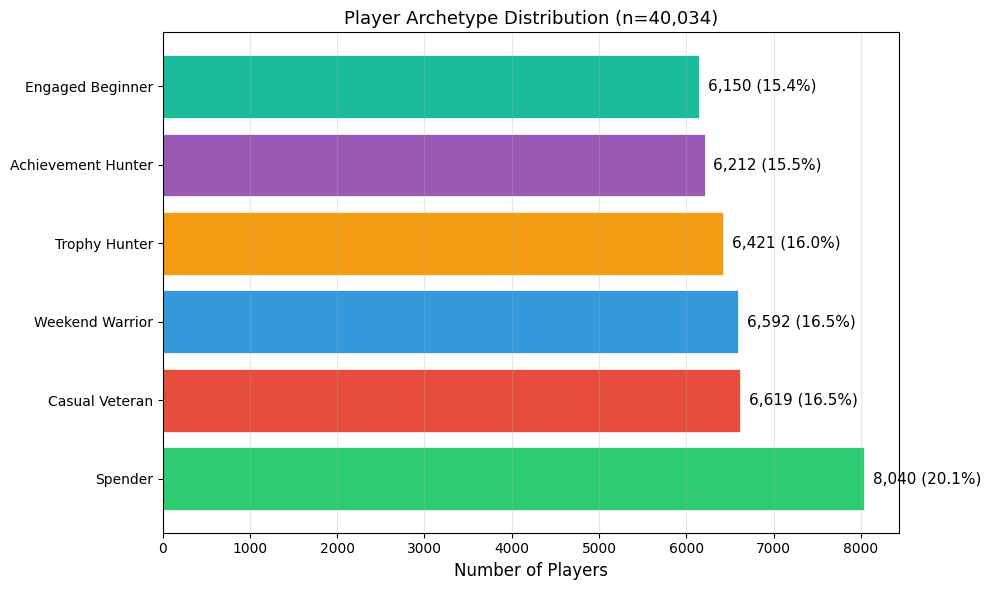

In [24]:
# Player Archetype Distribution

import matplotlib.pyplot as plt

archetype_counts = df['ArchetypeName'].value_counts()
names = archetype_counts.index.tolist()
values = archetype_counts.values.tolist()
colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(names, values, color=colors, edgecolor='white', linewidth=0.5)

for bar, count in zip(bars, values):
    pct = count / len(df) * 100
    ax.text(count + 100, bar.get_y() + bar.get_height()/2,
            f'{count:,} ({pct:.1f}%)', va='center', fontsize=11)

ax.set_xlabel('Number of Players', fontsize=12)
ax.set_title('Player Archetype Distribution (n=40,034)', fontsize=13)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('Clustering_figures/fig_4_2_archetype_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

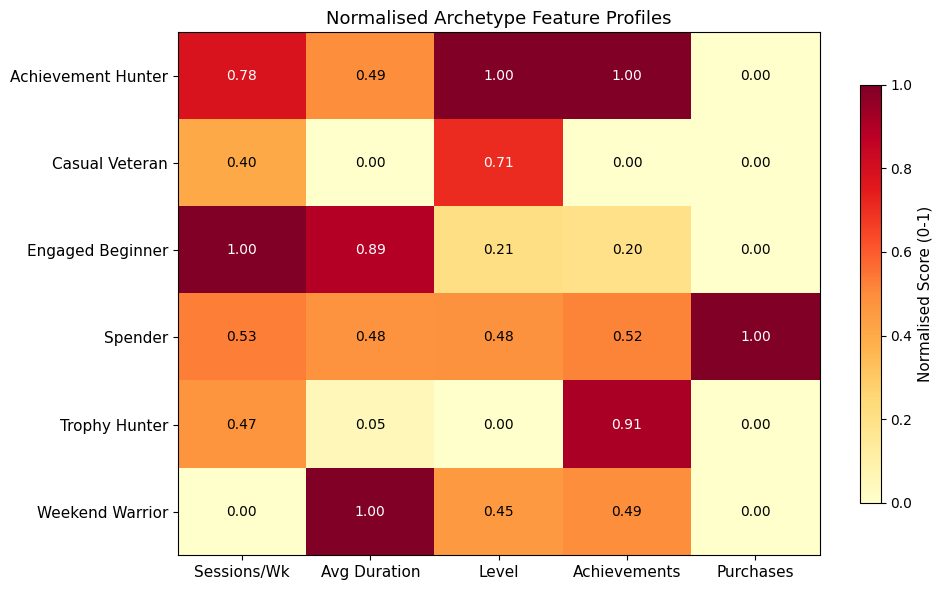

In [25]:
# Archetype Feature Profiles (Heatmap)

import matplotlib.pyplot as plt
import numpy as np

features = clustering_features
archetype_means = df.groupby('ArchetypeName')[features].mean()

mins = archetype_means.min(axis=0)
maxs = archetype_means.max(axis=0)
norm_df = (archetype_means - mins) / (maxs - mins)

display_cols = ['Sessions/Wk', 'Avg Duration', 'Level', 'Achievements', 'Purchases']
norm_vals = norm_df.values
row_labels = norm_df.index.tolist()

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(norm_vals, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(list(range(len(display_cols))))
ax.set_xticklabels(display_cols, fontsize=11)
ax.set_yticks(list(range(len(row_labels))))
ax.set_yticklabels(row_labels, fontsize=11)

for i in range(len(row_labels)):
    for j in range(len(display_cols)):
        val = norm_vals[i][j]
        color = 'white' if val > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10, color=color)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Normalised Score (0-1)', fontsize=11)
ax.set_title('Normalised Archetype Feature Profiles', fontsize=13)
plt.tight_layout()
plt.savefig('Clustering_figures/fig_4_3_archetype_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

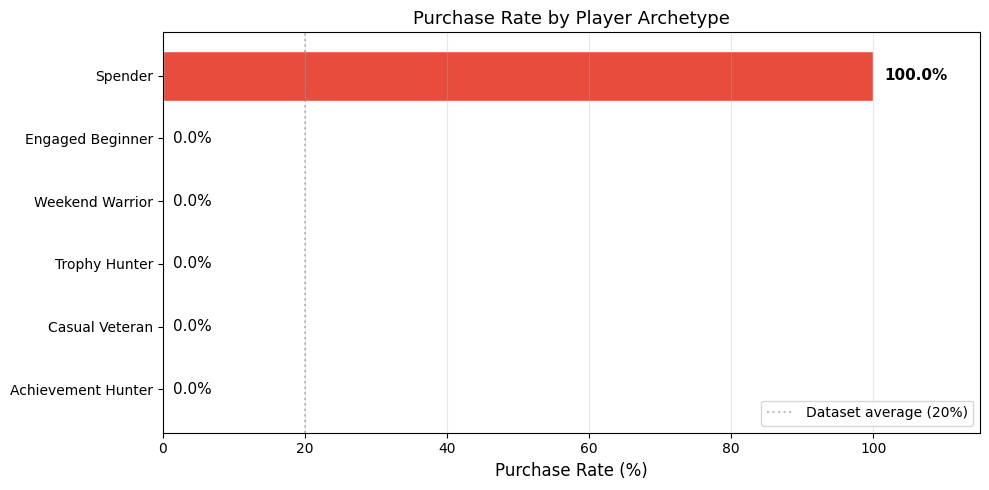

In [26]:
# Purchase Rate by Archetype (highlights Spender)

import matplotlib.pyplot as plt

pr = df.groupby('ArchetypeName')['InGamePurchases'].mean() * 100
pr_sorted = pr.sort_values(ascending=True)
names = pr_sorted.index.tolist()
rates = pr_sorted.values.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#e74c3c' if r > 50 else '#bdc3c7' for r in rates]
bars = ax.barh(names, rates, color=bar_colors, edgecolor='white')

for bar, rate in zip(bars, rates):
    weight = 'bold' if rate > 50 else 'normal'
    ax.text(rate + 1.5, bar.get_y() + bar.get_height()/2,
            f'{rate:.1f}%', va='center', fontsize=11, fontweight=weight)

ax.set_xlabel('Purchase Rate (%)', fontsize=12)
ax.set_title('Purchase Rate by Player Archetype', fontsize=13)
ax.set_xlim(0, 115)
ax.axvline(x=20, color='gray', linestyle=':', alpha=0.5, label='Dataset average (20%)')
ax.legend(fontsize=10)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('Clustering_figures/fig_4_4_purchase_by_archetype.png', dpi=300, bbox_inches='tight')
plt.show()